In [ ]:
import marimo as mo

# EDA — Vitaliza: Sistema de Inteligência de Retenção

**Objetivo pedagógico (PBL).** Cada seção explica o **como** (técnica) e o
**porquê** (decisão de negócio). A EDA não é enfeite: ela define as features,
revela vazamento potencial e fundamenta as recomendações de retenção.

**Dataset:** `data/gym_churn_us.csv` — 4.000 assinantes × 14 colunas.
**Alvo:** `Churn` (1 = cancelou). **Mapeamento ao case:** `Lifetime` = tempo de
assinatura; `Avg_class_frequency_*` = frequência semanal (histórica vs mês atual);
`Contract_period` ∈ {1, 6, 12} meses; `Group_visits` = participação em desafios.

In [ ]:
# Como: imports e carga via o mesmo loader do pipeline (fonte única de verdade).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.getcwd()))
from pipeline.data_loader import load_data, validate_data
from pipeline.features import add_derived_features

sns.set_theme(style="whitegrid")

## 1. Carga e inspeção

**Porquê:** antes de confiar no dado, confirmamos shape, tipos, nulos e a taxa
de churn. Um alvo desbalanceado muda a escolha de métricas (ROC/PR-AUC, não acurácia).

In [ ]:
df_raw = load_data()
report = validate_data(df_raw)
report  # shape, nulos, churn_rate, sha256

In [ ]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float64
 12  Avg

In [ ]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510250,0.499957,0.0,0.000000,1.000000,1.000000,1.000000
Near_Location,4000.0,0.845250,0.361711,0.0,1.000000,1.000000,1.000000,1.000000
Partner,4000.0,0.486750,0.499887,0.0,0.000000,0.000000,1.000000,1.000000
Promo_friends,4000.0,0.308500,0.461932,0.0,0.000000,0.000000,1.000000,1.000000
Phone,4000.0,0.903500,0.295313,0.0,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...
Month_to_end_contract,4000.0,4.322750,4.191297,1.0,1.000000,1.000000,6.000000,12.000000
Lifetime,4000.0,3.724750,3.749267,0.0,1.000000,3.000000,5.000000,31.000000
Avg_class_frequency_total,4000.0,1.879020,0.972245,0.0,1.180875,1.832768,2.536078,6.023668
Avg_class_frequency_current_month,4000.0,1.767052,1.052906,0.0,0.963003,1.719574,2.510336,6.146783


In [ ]:
# Nulos e duplicatas — limpeza.
null_dup = {
    "nulos_por_coluna": df_raw.isnull().sum().to_dict(),
    "linhas_duplicadas": int(df_raw.duplicated().sum()),
}
null_dup

**Leitura:** sem nulos e sem duplicatas; alvo binário; churn ≈ **26,5%**
(desbalanceado). **Decisão:** métricas primárias = ROC-AUC e PR-AUC; usaremos
`class_weight`/`scale_pos_weight`. A limpeza pesada (winsorização p99) fica no
pré-processador, **fit só no treino** (anti-leakage) — não aqui.

## 2. Features derivadas (case-críticas)

**Porquê:** o churn de academia é sobre o **movimento** do engajamento, não um
número isolado. Derivamos:
- `ratio_freq_atual_vs_lifetime` e `delta_freq` — queda de frequência (pré-churn);
- `flag_early_user` (Lifetime ≤ 1) — risco de desistência inicial;
- `flag_sleeping_dog` (Lifetime > 6 e freq atual < 0,5) — "cão que dorme";
- `contract_x_lifetime` — interação contrato × tempo.

In [ ]:
df = add_derived_features(df_raw)
df[[
    "ratio_freq_atual_vs_lifetime", "delta_freq", "flag_early_user",
    "flag_sleeping_dog", "contract_x_lifetime",
]].describe().T

,count,mean,std,min,25%,50%,75%,max
ratio_freq_atual_vs_lifetime,4000.0,0.893869,0.342980,0.000000,0.877713,0.984155,1.027531,7.244537
delta_freq,4000.0,-0.111968,0.321350,-1.856764,-0.141110,-0.022433,0.056744,1.060218
flag_early_user,4000.0,0.332500,0.471168,0.000000,0.000000,0.000000,1.000000,1.000000
flag_sleeping_dog,4000.0,0.013500,0.115417,0.000000,0.000000,0.000000,0.000000,1.000000
contract_x_lifetime,4000.0,20.348000,33.296675,0.000000,1.000000,6.000000,24.000000,372.000000


## 3. As 6 visualizações obrigatórias (SPEC §7.1)

### (a) Churn por tipo de contrato
**Porquê:** o case Vitaliza afirma que mensal cancela muito mais que anual.
Confirmamos na base: a alavanca central de retenção é **migração de contrato**.

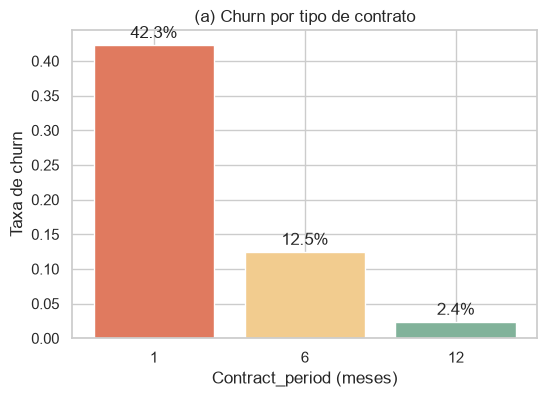

In [ ]:
ct = df.groupby("Contract_period")["Churn"].mean()
fig_a, ax_a = plt.subplots(figsize=(6, 4))
ax_a.bar(ct.index.astype(str), ct.values, color=["#e07a5f", "#f2cc8f", "#81b29a"])
ax_a.set_xlabel("Contract_period (meses)")
ax_a.set_ylabel("Taxa de churn")
ax_a.set_title("(a) Churn por tipo de contrato")
for _i, _v in enumerate(ct.values):
    ax_a.text(_i, _v + 0.01, f"{_v:.1%}", ha="center")
fig_a

### (b) Sobrevivência Kaplan-Meier por `Lifetime`
**Como:** tratamos `Lifetime` como tempo observado e `Churn` como evento.
**Porquê:** mostra **quando** o risco se concentra — a curva despenca cedo,
evidenciando a janela crítica de onboarding (primeiras semanas).

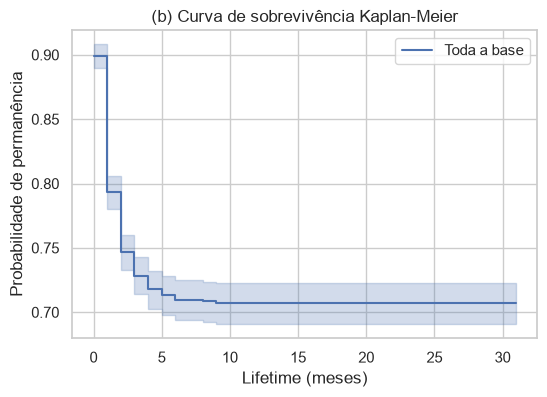

In [ ]:
kmf = KaplanMeierFitter()
fig_b, ax_b = plt.subplots(figsize=(6, 4))
kmf.fit(df["Lifetime"], event_observed=df["Churn"], label="Toda a base")
kmf.plot_survival_function(ax=ax_b)
ax_b.set_xlabel("Lifetime (meses)")
ax_b.set_ylabel("Probabilidade de permanência")
ax_b.set_title("(b) Curva de sobrevivência Kaplan-Meier")
fig_b

### (c) Boxplot — frequência do mês corrente por churn
**Porquê:** quem cancela frequenta bem menos no mês atual. `freq_current` é um
termômetro de engajamento — e uma feature acionável (nudges, desafios).

C:\Users\igorr\AppData\Local\Temp\marimo_34904\__marimo__cell_ROlb_.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="Avg_class_frequency_current_month", ax=ax_c,


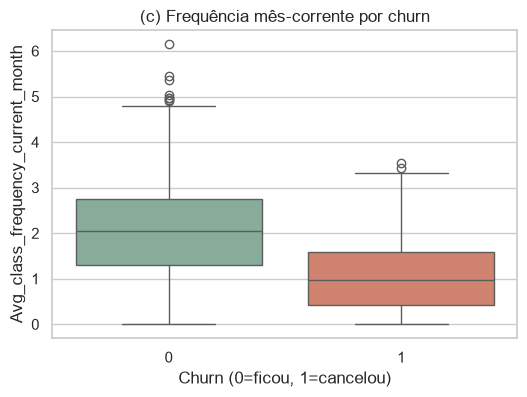

In [ ]:
fig_c, ax_c = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="Churn", y="Avg_class_frequency_current_month", ax=ax_c,
            palette=["#81b29a", "#e07a5f"])
ax_c.set_title("(c) Frequência mês-corrente por churn")
ax_c.set_xlabel("Churn (0=ficou, 1=cancelou)")
fig_c

### (d) Heatmap de correlação
**Porquê:** mapeia redundância e proxies do alvo. **Atenção a leakage:**
`Month_to_end_contract` correlaciona ~0,97 com `Contract_period` (relógio do
contrato) — por isso é **removida** do modelo (ver `leakage_audit.py`).

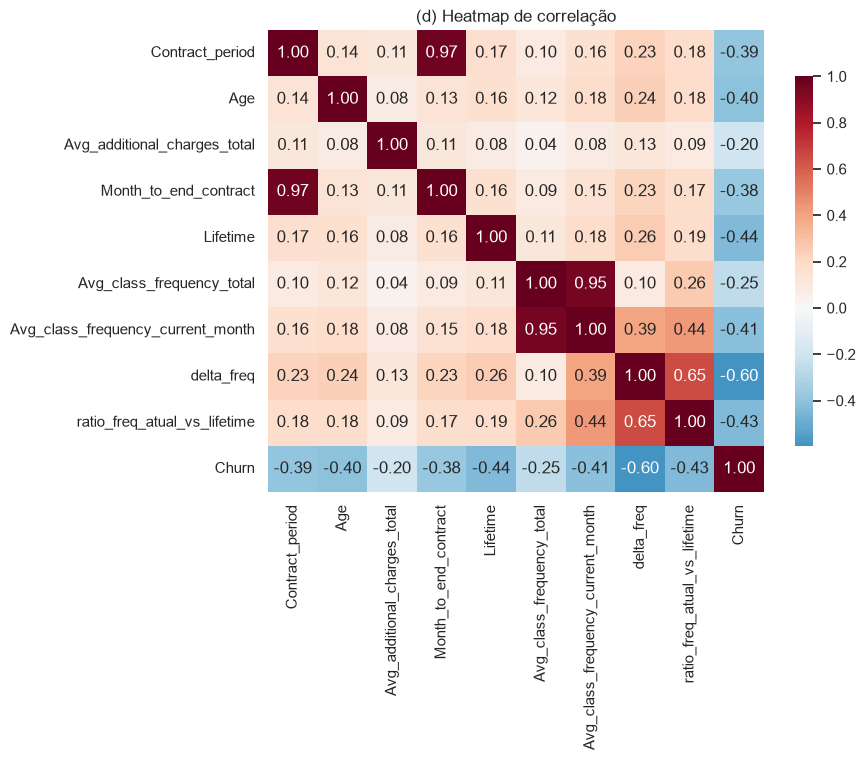

In [ ]:
corr_cols = [
    "Contract_period", "Age", "Avg_additional_charges_total",
    "Month_to_end_contract", "Lifetime", "Avg_class_frequency_total",
    "Avg_class_frequency_current_month", "delta_freq",
    "ratio_freq_atual_vs_lifetime", "Churn",
]
fig_d, ax_d = plt.subplots(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax_d, cbar_kws={"shrink": 0.8})
ax_d.set_title("(d) Heatmap de correlação")
fig_d

### (e) Scatter freq_total × freq_atual (sleeping dogs destacados)
**Porquê:** a diagonal separa quem mantém o ritmo de quem desacelerou. Os
**sleeping dogs** (laranja) ficam no canto inferior — antigos hoje inativos.
Regra de negócio: **não acordá-los** com campanha proativa.

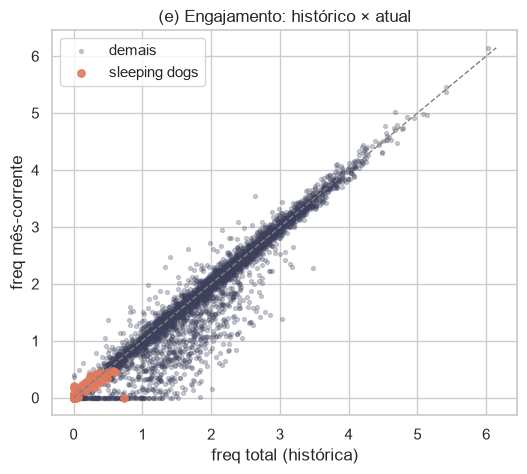

In [ ]:
fig_e, ax_e = plt.subplots(figsize=(6, 5))
normal = df[df["flag_sleeping_dog"] == 0]
dogs = df[df["flag_sleeping_dog"] == 1]
ax_e.scatter(normal["Avg_class_frequency_total"],
             normal["Avg_class_frequency_current_month"],
             s=8, alpha=0.25, color="#3d405b", label="demais")
ax_e.scatter(dogs["Avg_class_frequency_total"],
             dogs["Avg_class_frequency_current_month"],
             s=28, alpha=0.9, color="#e07a5f", label="sleeping dogs")
lim = max(df["Avg_class_frequency_total"].max(),
          df["Avg_class_frequency_current_month"].max())
ax_e.plot([0, lim], [0, lim], "--", color="gray", lw=1)
ax_e.set_xlabel("freq total (histórica)")
ax_e.set_ylabel("freq mês-corrente")
ax_e.set_title("(e) Engajamento: histórico × atual")
ax_e.legend()
fig_e

### (f) Churn por cohort de entrada (`Lifetime`)
**Porquê:** churn por tempo de casa. As cohorts recentes (Lifetime baixo)
concentram o churn — confirma a janela de onboarding como prioridade.

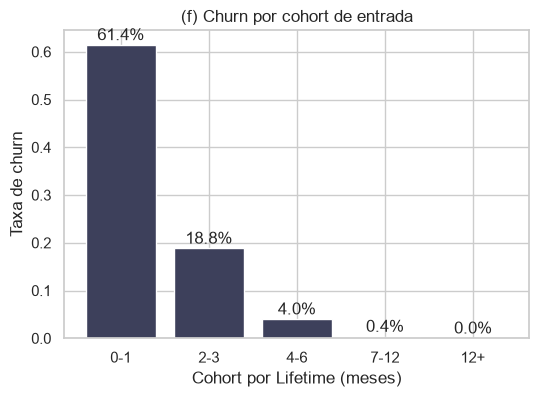

In [ ]:
bins = [-0.1, 1, 3, 6, 12, df["Lifetime"].max() + 1]
labels = ["0-1", "2-3", "4-6", "7-12", "12+"]
df_c = df.copy()
df_c["cohort"] = pd.cut(df_c["Lifetime"], bins=bins, labels=labels)
ch = df_c.groupby("cohort", observed=True)["Churn"].mean()
fig_f, ax_f = plt.subplots(figsize=(6, 4))
ax_f.bar(ch.index.astype(str), ch.values, color="#3d405b")
ax_f.set_xlabel("Cohort por Lifetime (meses)")
ax_f.set_ylabel("Taxa de churn")
ax_f.set_title("(f) Churn por cohort de entrada")
for _i, _v in enumerate(ch.values):
    ax_f.text(_i, _v + 0.01, f"{_v:.1%}", ha="center")
fig_f

## 4. Segmentação acionável

**Porquê:** traduz a análise em grupos com política de ação (conecta ao advisor).
- **Early droppers:** `Lifetime ≤ 1` — maior risco; foco em onboarding.
- **Sleeping dogs:** `Lifetime > 6` e `freq atual < 0,5` — **não acordar**.
- **Anuais uso-zero:** contrato 12m com `freq atual ≈ 0` — risco silencioso de
  não-renovação; abordagem de valor (não desconto).

In [ ]:
seg = {}
early = df[df["flag_early_user"] == 1]
seg["early_droppers"] = {"n": int(len(early)), "churn_rate": round(float(early["Churn"].mean()), 4)}
dogs2 = df[df["flag_sleeping_dog"] == 1]
seg["sleeping_dogs"] = {"n": int(len(dogs2)), "churn_rate": round(float(dogs2["Churn"].mean()), 4)}
annual_zero = df[(df["Contract_period"] >= 12) & (df["Avg_class_frequency_current_month"] < 0.1)]
seg["anuais_uso_zero"] = {"n": int(len(annual_zero)), "churn_rate": round(float(annual_zero["Churn"].mean()), 4) if len(annual_zero) else None}
seg

## 5. Conclusões da EDA

1. Contrato é a alavanca-mãe: **mensal ~42% vs anual ~2,4%** de churn.
2. O churn é precoce: cohort `Lifetime 0–1` domina os cancelamentos.
3. Queda de frequência (`delta_freq`) é o sinal mais forte de pré-churn.
4. **Sleeping dogs são estáveis** (churn ~1,9%) — confirma "não acordar".
5. Comunidade reduz churn: `Group_visits=1` e indicação cortam o churn ~à metade.

As 10 recomendações acionáveis detalhadas estão em `eda_report.md` (raiz do repo).
*Guardrail:* correlação ≠ causalidade; o modelo prioriza, a operação decide.